In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(
    str(project_root / "src")
)

In [2]:
import networkx as nx

from atlas.paper_similarity import (
    paper_similarity
)

In [18]:
g_autokaggle = nx.read_graphml(
    "../data/graphs/autokaggle.graphml"
)

g_aide = nx.read_graphml(
    "../data/graphs/aide.graphml"
)

g_data_interpreter = nx.read_graphml(
    "../data/graphs/datainterpreter.graphml"
)

g_ai_scientist = nx.read_graphml(
    "../data/graphs/ai_scientist.graphml"
)

g_swe_agent = nx.read_graphml(
    "../data/graphs/swe_agent.graphml"
)

g_openhands = nx.read_graphml(
    "../data/graphs/openhands.graphml"
)

In [6]:
print(
    paper_similarity(
        g_aide,
        g_ai_scientist
    )
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

{'num_matches': 2, 'avg_score': np.float32(0.75825596), 'max_score': np.float32(0.84802437)}


In [19]:
graphs = {
    "AutoKaggle": g_autokaggle,
    "AIDE": g_aide,
    "DataInterpreter": g_data_interpreter,
    "AIScientist": g_ai_scientist,
    "SWEAgent": g_swe_agent,
    "OpenHands": g_openhands
}

for name_a, graph_a in graphs.items():

    for name_b, graph_b in graphs.items():

        if name_a >= name_b:
            continue

        result = paper_similarity(
            graph_a,
            graph_b
        )

        print(
            f"{name_a} ↔ {name_b}"
        )

        print(result)

        print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

AutoKaggle ↔ DataInterpreter
{'num_matches': 1, 'avg_score': np.float32(0.57442915), 'max_score': np.float32(0.57442915)}



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

AutoKaggle ↔ SWEAgent
{'num_matches': 1, 'avg_score': np.float32(0.7247398), 'max_score': np.float32(0.7247398)}



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

AIScientist ↔ SWEAgent
{'num_matches': 3, 'avg_score': np.float32(0.641403), 'max_score': np.float32(0.6738309)}



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

AIScientist ↔ OpenHands
{'num_matches': 3, 'avg_score': np.float32(0.66590786), 'max_score': np.float32(0.7434559)}



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

OpenHands ↔ SWEAgent
{'num_matches': 6, 'avg_score': np.float32(0.6926382), 'max_score': np.float32(1.0000001)}



In [20]:
import pandas as pd

paper_names = list(graphs.keys())

similarity_matrix = pd.DataFrame(
    index=paper_names,
    columns=paper_names,
    dtype=float
)

for name_a, graph_a in graphs.items():

    for name_b, graph_b in graphs.items():

        if name_a == name_b:
            similarity_matrix.loc[name_a, name_b] = 0
            continue

        result = paper_similarity(
            graph_a,
            graph_b
        )

        similarity_matrix.loc[
            name_a,
            name_b
        ] = result["num_matches"]

similarity_matrix

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,AutoKaggle,AIDE,DataInterpreter,AIScientist,SWEAgent,OpenHands
AutoKaggle,0.0,2.0,1.0,1.0,1.0,3.0
AIDE,2.0,0.0,0.0,2.0,3.0,5.0
DataInterpreter,1.0,0.0,0.0,1.0,2.0,3.0
AIScientist,1.0,2.0,1.0,0.0,3.0,3.0
SWEAgent,1.0,3.0,2.0,3.0,0.0,6.0
OpenHands,3.0,5.0,3.0,3.0,6.0,0.0


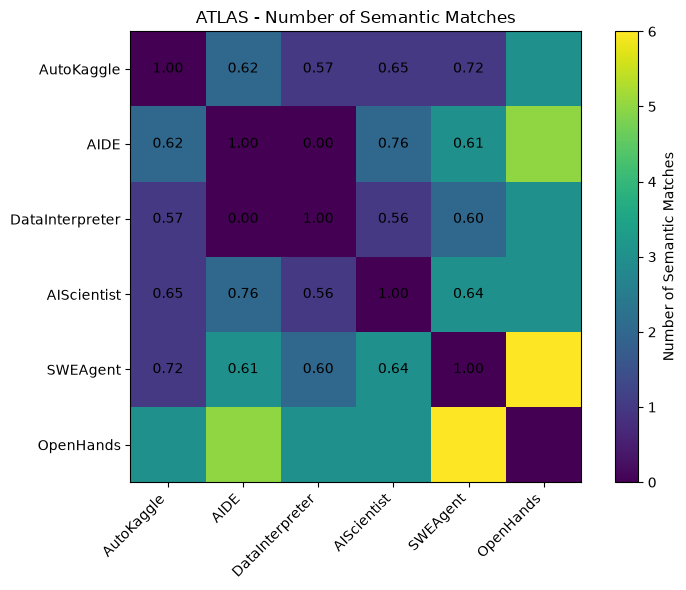

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    similarity_matrix,
    interpolation="nearest"
)

plt.colorbar(
    label="Number of Semantic Matches"
)

plt.xticks(
    range(len(similarity_matrix.columns)),
    similarity_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(similarity_matrix.index)),
    similarity_matrix.index
)

plt.title(
    "ATLAS - Number of Semantic Matches"
)

for i in range(len(avg_score_matrix.index)):
    for j in range(len(avg_score_matrix.columns)):

        plt.text(
            j,
            i,
            f"{avg_score_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

In [22]:
avg_score_matrix = pd.DataFrame(
    index=paper_names,
    columns=paper_names,
    dtype=float
)

for name_a, graph_a in graphs.items():

    for name_b, graph_b in graphs.items():

        if name_a == name_b:
            avg_score_matrix.loc[
                name_a,
                name_b
            ] = 1.0

            continue

        result = paper_similarity(
            graph_a,
            graph_b
        )

        avg_score_matrix.loc[
            name_a,
            name_b
        ] = result["avg_score"]

avg_score_matrix

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,AutoKaggle,AIDE,DataInterpreter,AIScientist,SWEAgent,OpenHands
AutoKaggle,1.000000,0.619348,0.574429,0.652816,0.724740,0.883802
AIDE,0.619348,1.000000,0.000000,0.758256,0.606239,0.587435
DataInterpreter,0.574429,0.000000,1.000000,0.560932,0.602505,0.594741
AIScientist,0.652816,0.758256,0.560932,1.000000,0.641403,0.665908
SWEAgent,0.724740,0.606239,0.602505,0.641403,1.000000,0.692638
OpenHands,0.883802,0.587435,0.594741,0.665908,0.692638,1.000000


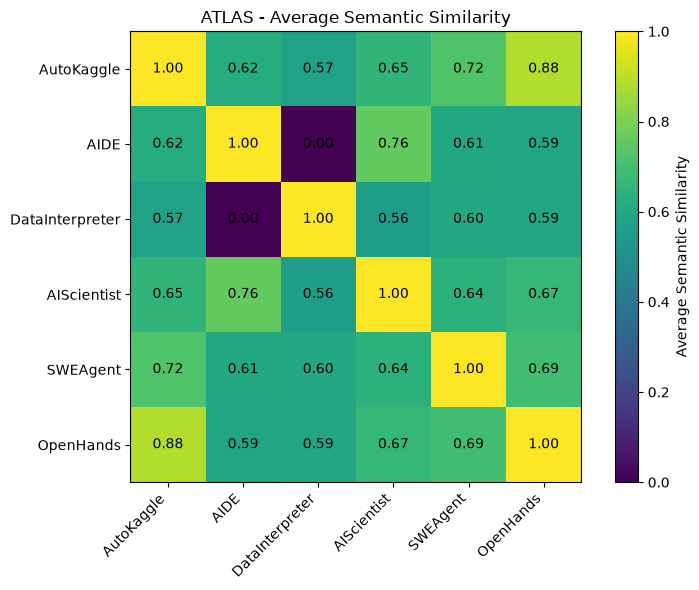

In [23]:
plt.figure(figsize=(8, 6))

plt.imshow(
    avg_score_matrix,
    interpolation="nearest"
)

plt.colorbar(
    label="Average Semantic Similarity"
)

plt.xticks(
    range(len(avg_score_matrix.columns)),
    avg_score_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(avg_score_matrix.index)),
    avg_score_matrix.index
)

plt.title(
    "ATLAS - Average Semantic Similarity"
)

for i in range(len(avg_score_matrix.index)):
    for j in range(len(avg_score_matrix.columns)):

        plt.text(
            j,
            i,
            f"{avg_score_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

In [24]:
avg_score_matrix.to_csv(
    "../data/results/paper_similarity.csv"
)

plt.savefig(
    "../data/results/paper_similarity_heatmap.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>